## Bank Customer Churn Prediction

---

###  Business Problem

In banking, **acquiring a new customer costs 5–7x more than retaining an existing one.**
Therefore, the ability to **predict customers likely to churn** before they make that decision is one of the most valuable tools in any Retention Strategy.

> **Customer Churn** = A customer who closes their account or stops engaging with the bank.

---

###  Objective

Build a Machine Learning model capable of:
- **Identifying customers most at risk of churning** with high accuracy
- **Prioritizing Retention team interventions** based on predicted churn probability
- Delivering **actionable insights** for Product and CRM teams

---

###  Dataset

| Property | Details |
|---|---|
| **Source** | Bank Customer Churn Records (Kaggle) |
| **Size** | ~10,000 customers |
| **Target** | `Exited` — 1 = Churned, 0 = Retained |
| **Features** | Demographics, financial behavior, satisfaction score, card type |

---

## Importing Necessary Libraries

> Here we import all libraries needed throughout the project — from data processing (`pandas`, `numpy`), to visualization (`matplotlib`, `seaborn`), to ML algorithms and evaluation tools from `sklearn`. We also configure default plot styles upfront to keep visuals consistent across the entire notebook.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix , roc_auc_score 
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import joblib

sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({
    'figure.figsize'   : (9, 5),
    'figure.dpi'       : 120,
    'axes.titlesize'   : 14,
    'axes.titlepad'    : 12,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 12,
    'ytick.labelsize'  : 10,
    'xtick.labelsize'  : 10,
})


## Data Collection & Loading


In [ ]:
data = pd.read_csv('Dataset/Customer-Churn-Records.csv')

## Data Understanding

> Before making any changes to the data, we need to understand it first. We inspect the dataset shape, column types, and value distributions — this helps us identify potential issues and plan our preprocessing strategy.

### · Shape & Columns
> We check the number of rows and columns, and the data type of each feature (numeric / object). This determines which columns need encoding and which can be used directly.

In [4]:
print (f'Shape : {data.shape[0]} rows x {data.shape[1]} columns')
print ('Columns :')
print (data.dtypes.to_string())

Shape : 10000 rows x 18 columns
Columns :
RowNumber               int64
CustomerId              int64
Surname                object
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64


### · Binary Features Distribution
> Binary columns (0/1) such as `Exited` and `Complain` have a special distribution. We inspect class ratios early on to detect any **class imbalance** before modeling.

In [5]:
binary_cols = [
    'HasCrCard',
    'IsActiveMember',
    'Exited',
    'Complain'
]
for col in binary_cols:
    print(f"\nColumn: {col}")
    print(data[col].value_counts())


Column: HasCrCard
HasCrCard
1    7055
0    2945
Name: count, dtype: int64

Column: IsActiveMember
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

Column: Exited
Exited
0    7962
1    2038
Name: count, dtype: int64

Column: Complain
Complain
0    7956
1    2044
Name: count, dtype: int64


### · Sample Rows
> We display the first and last rows of the dataset. This reveals the actual structure of the data and any formatting issues or unexpected values that are not visible in the dtype summary.

In [6]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [7]:
data.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0,0,3,DIAMOND,911


### · Basic Statistics
> We compute descriptive statistics such as mean, standard deviation, min, and max for key columns. This helps identify potential outliers and gives us a sense of each feature's value range.

In [8]:
cols = [
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary',
    'Exited',
    'Complain',
    'Satisfaction Score',
    'Point Earned'
]
data[cols].describe()

,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


## Data Cleaning
> Clean data leads to better models. In this stage we remove duplicates and handle missing values, then detect outliers — all before any analysis or modeling begins.

### · Duplicate Rows
> Duplicate rows cause the model to over-learn the same information and can bias results. We remove them if found.

In [9]:
dup_counts = data.duplicated().sum()
if dup_counts > 0 :
    data = data.drop_duplicates()
    print (f"Duplicates Removed. New Shape : {data.shape}")
else :
    print ('No Duplicates , Dataset Is Clean.')

No Duplicates , Dataset Is Clean.


### · Missing Values
> Missing values cause errors in modeling or skew results. We identify which columns have gaps and their percentage, then decide on the appropriate handling strategy.

In [10]:
missing     = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df  = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
}).sort_values('Missing Count', ascending=False)
print(missing_df.to_string())

                    Missing Count  Missing %
RowNumber                       0        0.0
CustomerId                      0        0.0
Surname                         0        0.0
CreditScore                     0        0.0
Geography                       0        0.0
Gender                          0        0.0
Age                             0        0.0
Tenure                          0        0.0
Balance                         0        0.0
NumOfProducts                   0        0.0
HasCrCard                       0        0.0
IsActiveMember                  0        0.0
EstimatedSalary                 0        0.0
Exited                          0        0.0
Complain                        0        0.0
Satisfaction Score              0        0.0
Card Type                       0        0.0
Point Earned                    0        0.0


### · Outlier Detection (IQR Method)

> We use the **IQR Rule** to detect outliers in continuous columns. Detecting outliers does not necessarily mean removing them — they may carry real signal — but we need to be aware of them before modeling.

In [11]:
numeric_cols = [
    'CreditScore',
    'Age',
    'Balance',
    'EstimatedSalary',
    'Satisfaction Score',
    'Point Earned'
]

outlier_summary = []
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_out = ((data[col] < lower) | (data[col] > upper)).sum()

    outlier_summary.append({
        'Column': col,
        'Outliers': n_out,
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2)
    })

out_df = pd.DataFrame(outlier_summary).set_index('Column')

print(out_df)
print(f"\nTotal outliers detected: {out_df['Outliers'].sum()}")

                    Outliers  Lower Bound  Upper Bound
Column                                                
CreditScore               15       383.00       919.00
Age                      359        14.00        62.00
Balance                    0   -191466.36    319110.60
EstimatedSalary            0    -96577.10    296967.45
Satisfaction Score         0        -1.00         7.00
Point Earned               0      -176.50      1387.50

Total outliers detected: 374


### · Boxplot For Numerical Features
> Boxplots visually highlight outliers and show the spread and distribution of each numeric feature. Much easier than raw numbers for spotting anomalies.

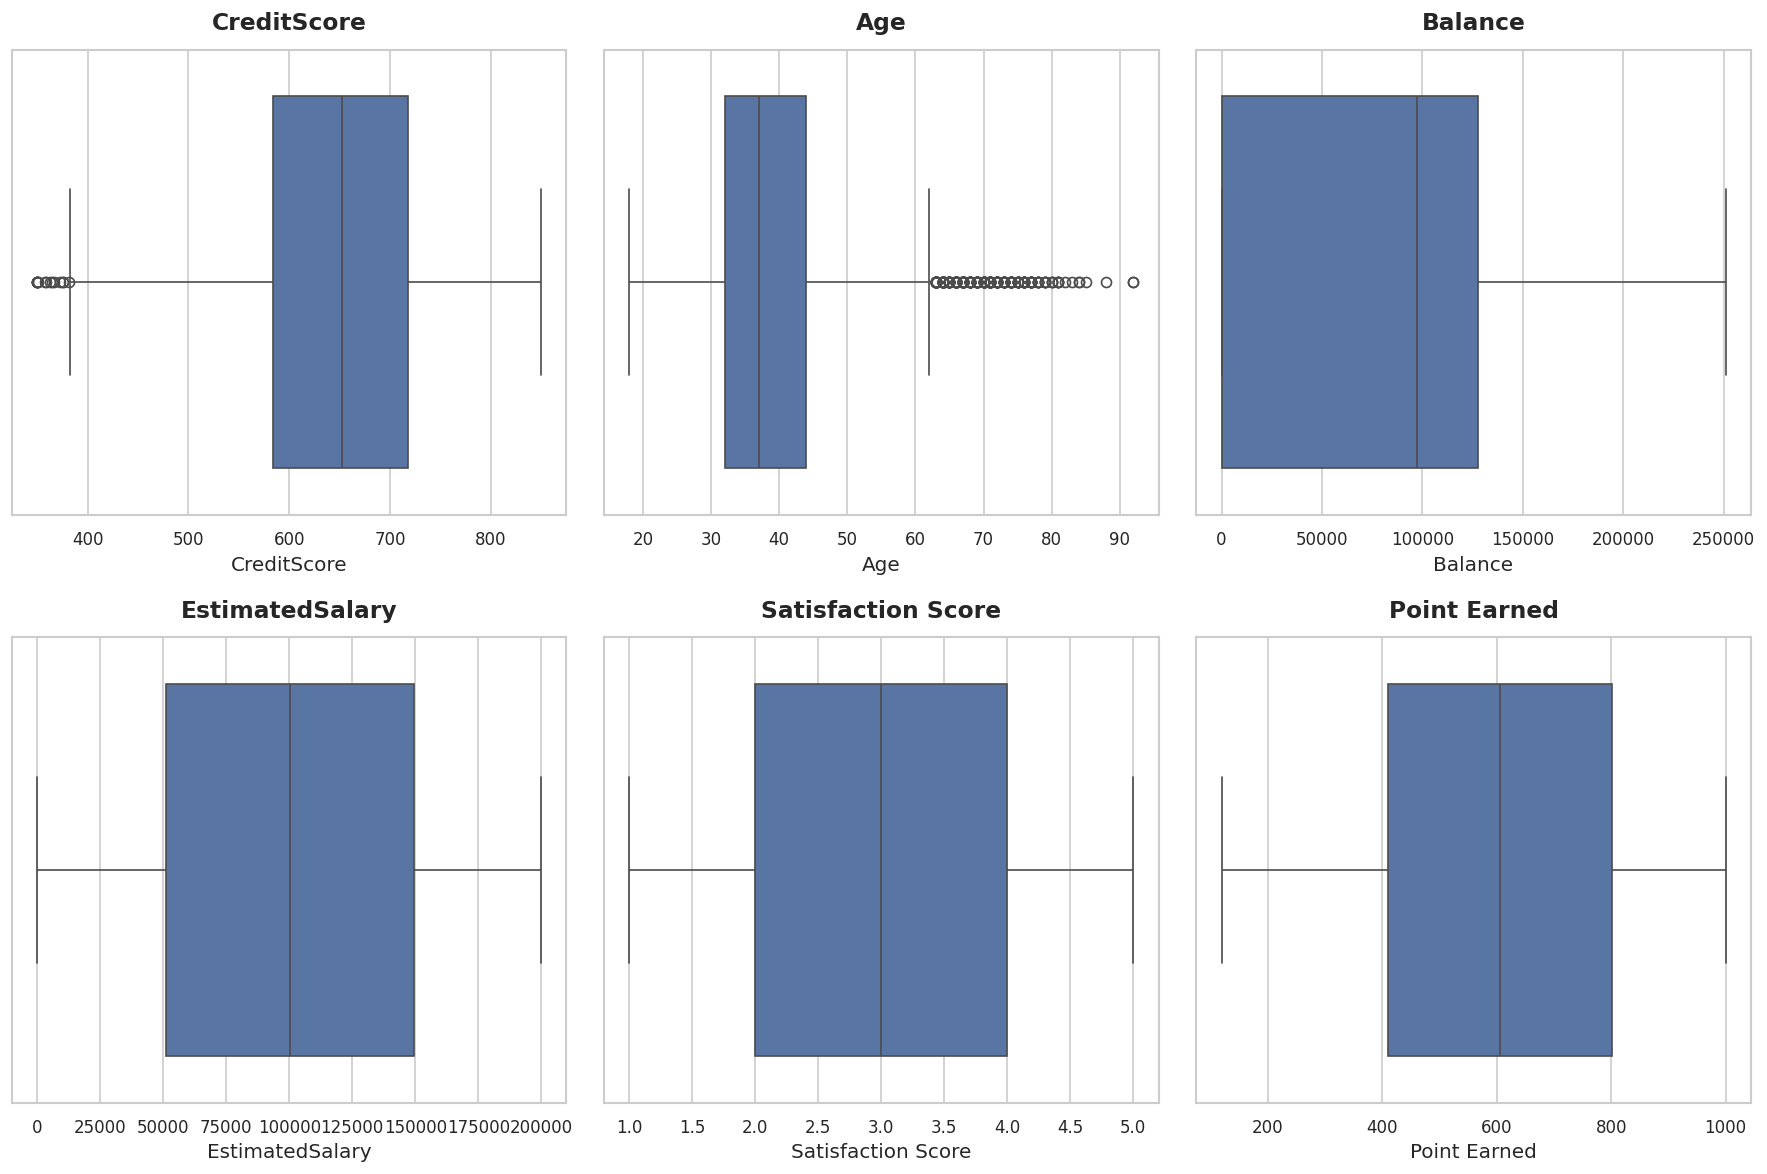

In [12]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### · Create Variable For Categrical
> In this step, we define the categorical feature columns that will later be used for encoding. Defining them early helps keep the preprocessing pipeline more organized, readable, and easier to maintain.

In [13]:
cat_cols = [
    'Geography',
    'Gender',
    'Card Type'
]

## EDA (Exploratory Data Analysis)
> EDA is the stage where we deeply understand the data — we examine the distribution of each variable and its relationship with the target (`Exited`). The insights gained here drive Feature Engineering and Modeling decisions.

### · Univariate Analysis
> We study each variable independently to understand its distribution and shape — is it normal? skewed? dominated by a single value? This determines what transformations may be needed.

#### · Distribution For Numerical Columns
> We plot a Histogram with KDE for each numeric column to visualize its distribution shape and identify skewness or concentration around specific values.

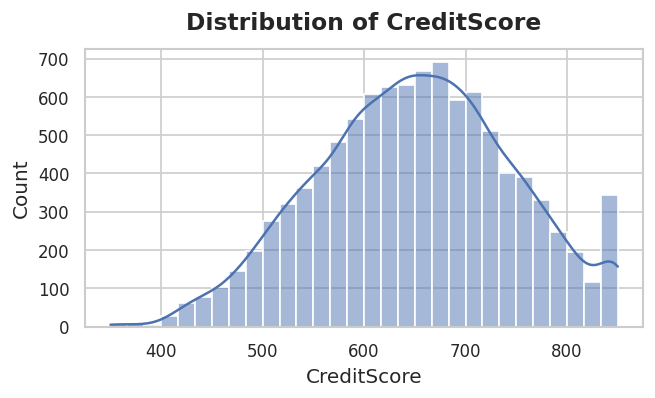

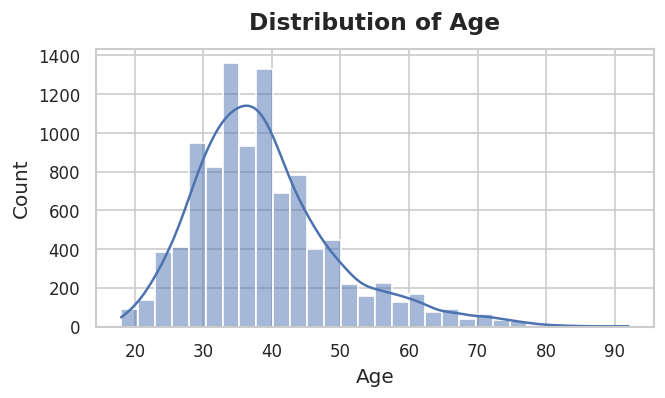

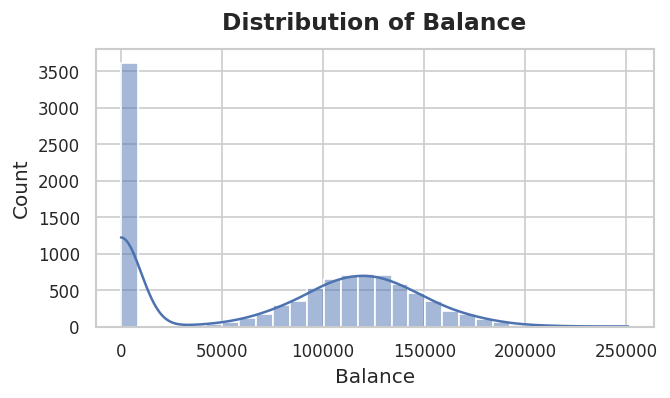

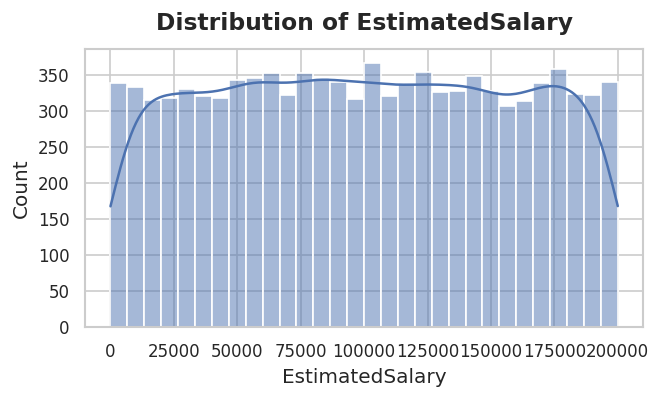

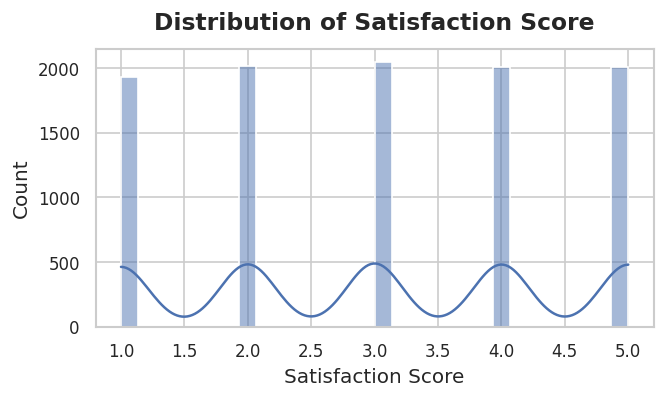

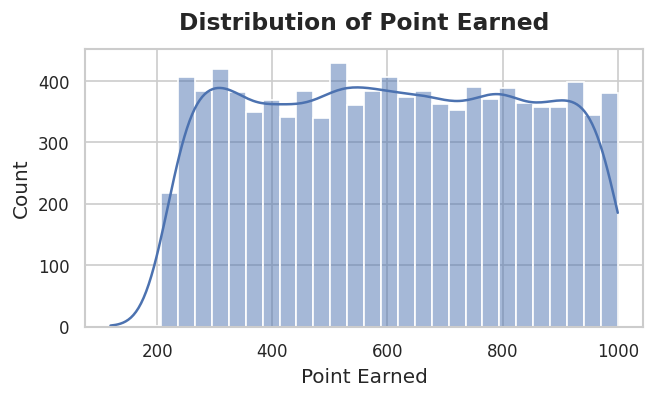

In [14]:
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

#### · Distribution for Binary Columns
> We count each value in binary columns. This is important for detecting **class imbalance** in the target variable early on.

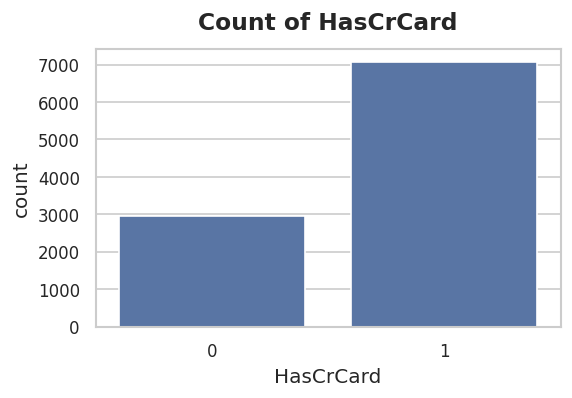

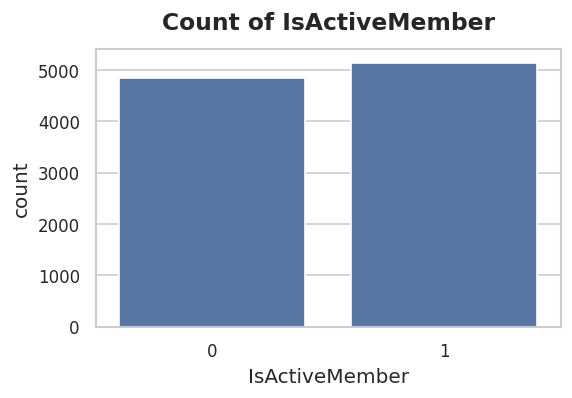

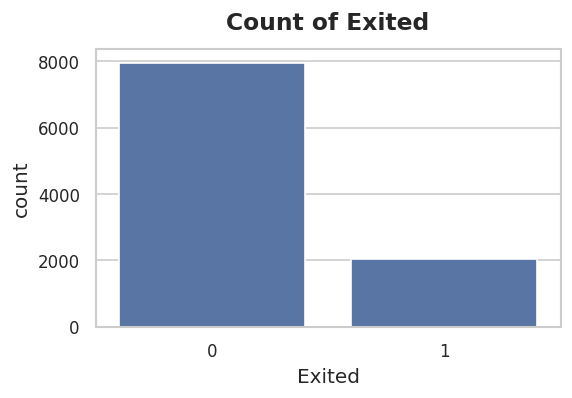

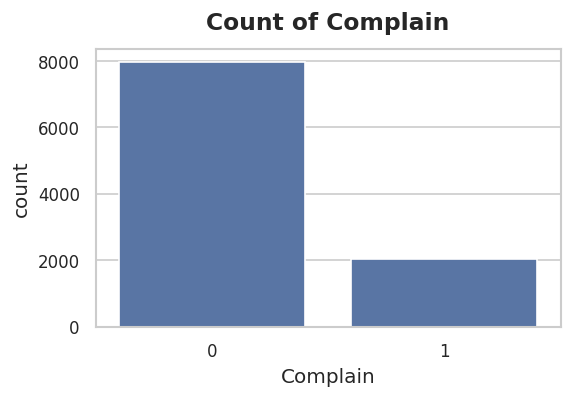

In [15]:
for col in binary_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=data[col])
    plt.title(f'Count of {col}')
    plt.show()

#### · Distribution For Categorical Columns
> We visualize the distribution of categorical features like country, card type, and gender — important for spotting rare categories that may need grouping.

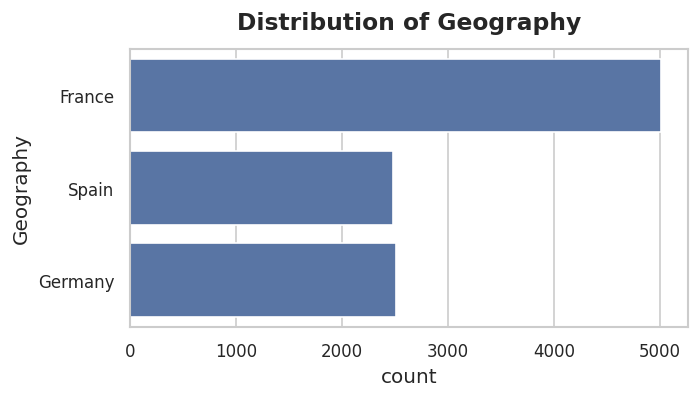

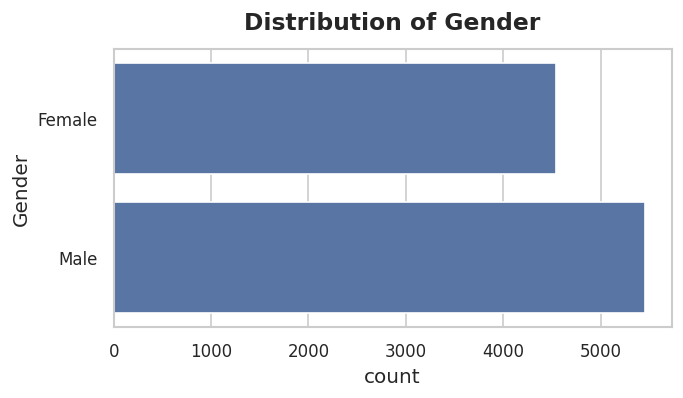

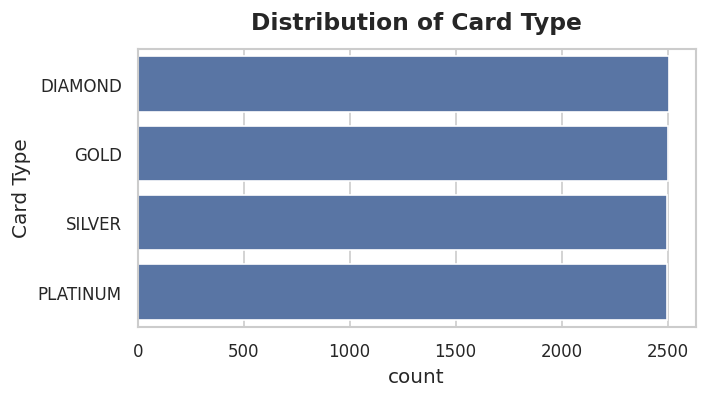

In [16]:
for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(y=data[col])
    plt.title(f'Distribution of {col}')
    plt.show()

### · Bivariate Analysis
> We study the relationship between each variable and the target (`Exited`). This is the core of EDA in Classification problems — it reveals which features have real **predictive power**.

#### · Card Type vs Customer Churn (Exited)
Analyzing whether the type of credit card affects customer churn behavior.

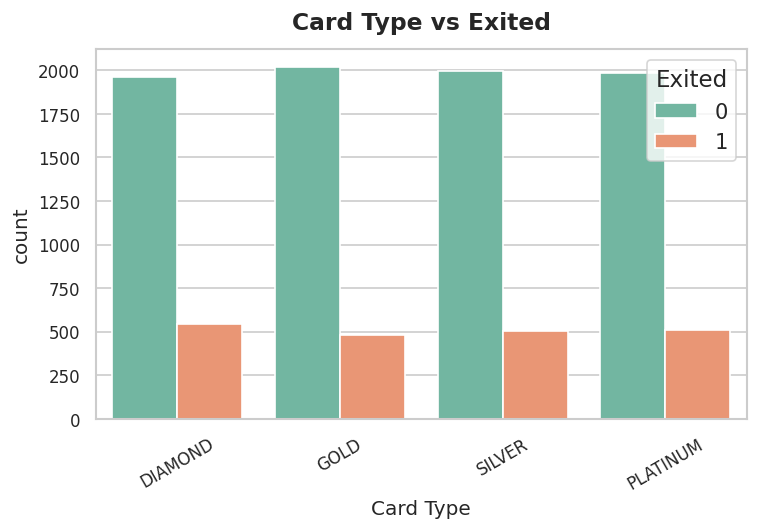

In [17]:
plt.figure(figsize=(7,4))
sns.countplot(x='Card Type', hue='Exited', data=data, palette='Set2')
plt.title('Card Type vs Exited')
plt.xticks(rotation=30)
plt.show()

#### · Estimated Salary vs Exited
Checking if customer income level influences churn probability.

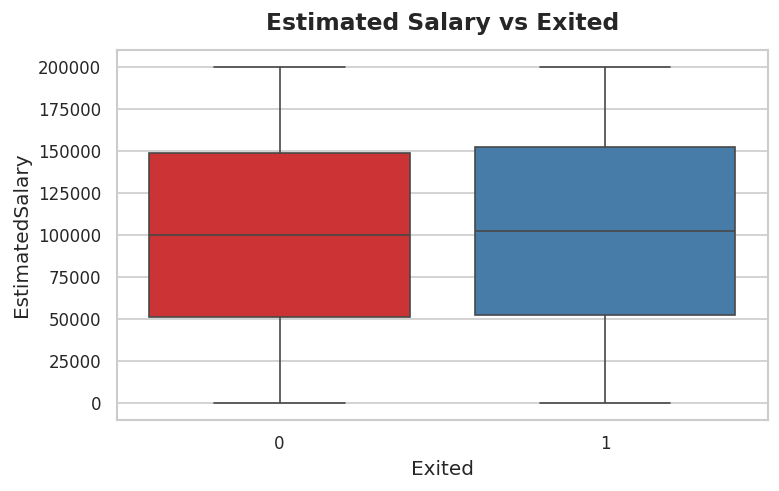

In [18]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Exited', y='EstimatedSalary', data=data, palette='Set1')
plt.title('Estimated Salary vs Exited')
plt.show()

#### · Account Balance vs Exited
Understanding how account balance relates to customer retention.

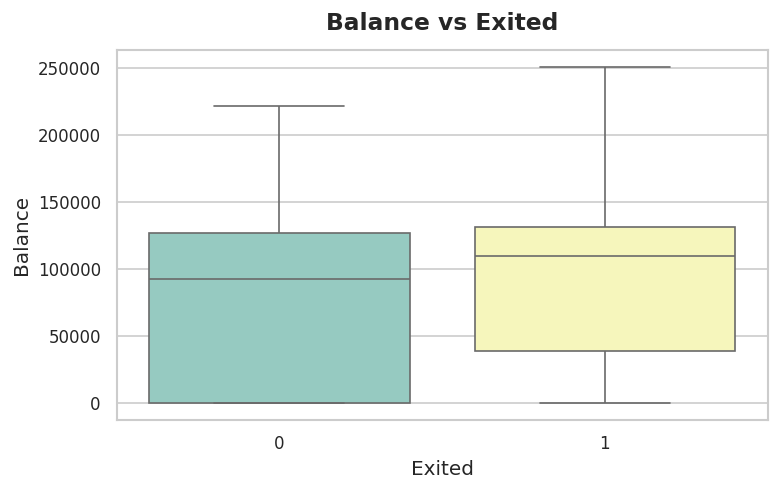

In [19]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Exited', y='Balance', data=data, palette='Set3')
plt.title('Balance vs Exited')
plt.show()

#### · Has Credit Card vs Exited
Analyzing whether owning a credit card affects churn.

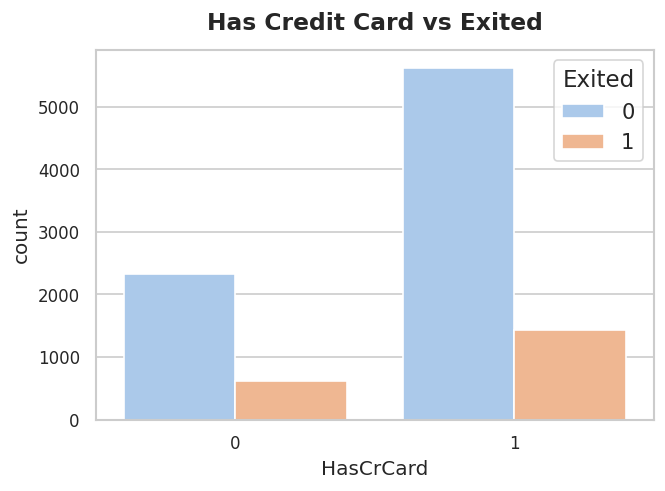

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='HasCrCard', hue='Exited', data=data, palette='pastel')
plt.title('Has Credit Card vs Exited')
plt.show()

#### · Tenure vs Exited
Studying the relationship between customer loyalty duration and churn.

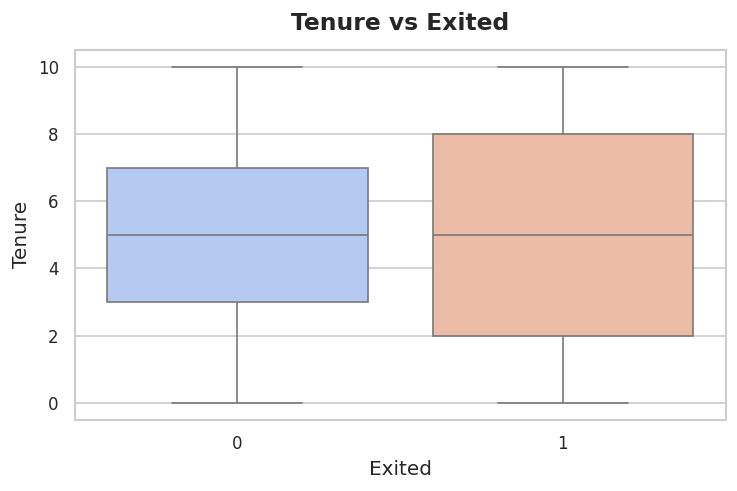

In [21]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Exited', y='Tenure', data=data, palette='coolwarm')
plt.title('Tenure vs Exited')
plt.show()

#### · Age vs Exited
Exploring how customer age impacts churn behavior.

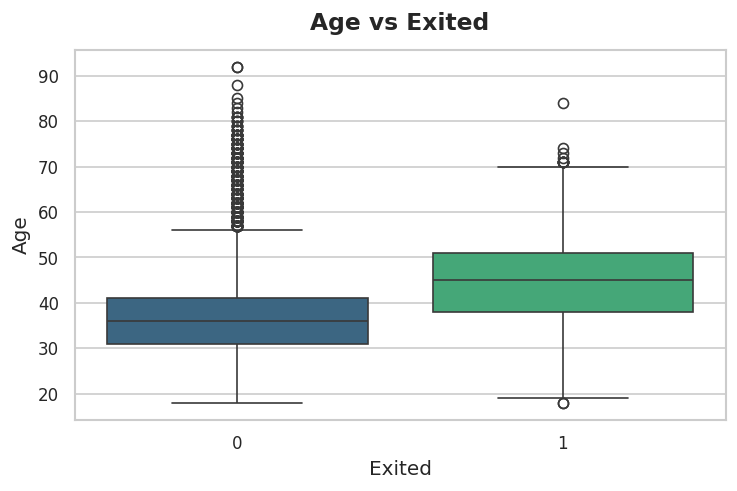

In [22]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Exited', y='Age', data=data, palette='viridis')
plt.title('Age vs Exited')
plt.show()

#### · Active Membership vs Exited
Checking if active users are less likely to leave the bank.

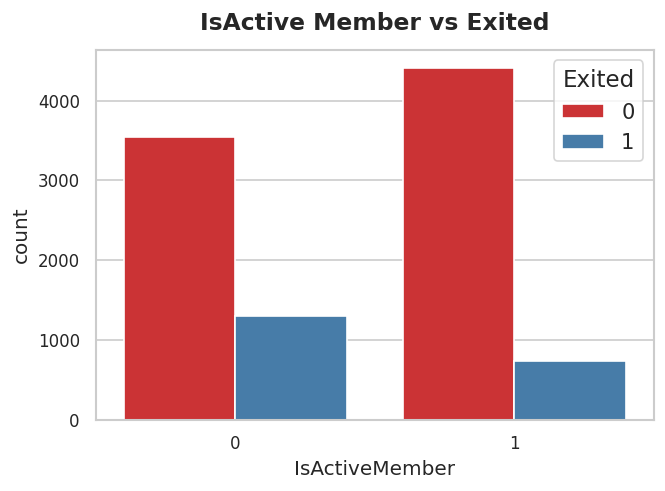

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='IsActiveMember', hue='Exited', data=data, palette='Set1')
plt.title('IsActive Member vs Exited')
plt.show()

#### · Correlation Heatmap
> We compute the Pearson correlation between all numeric features and visualize it as a heatmap. High correlation with `Exited` (target) indicates a strong predictor. High correlation between two features may indicate **multicollinearity**, which can affect Logistic Regression.


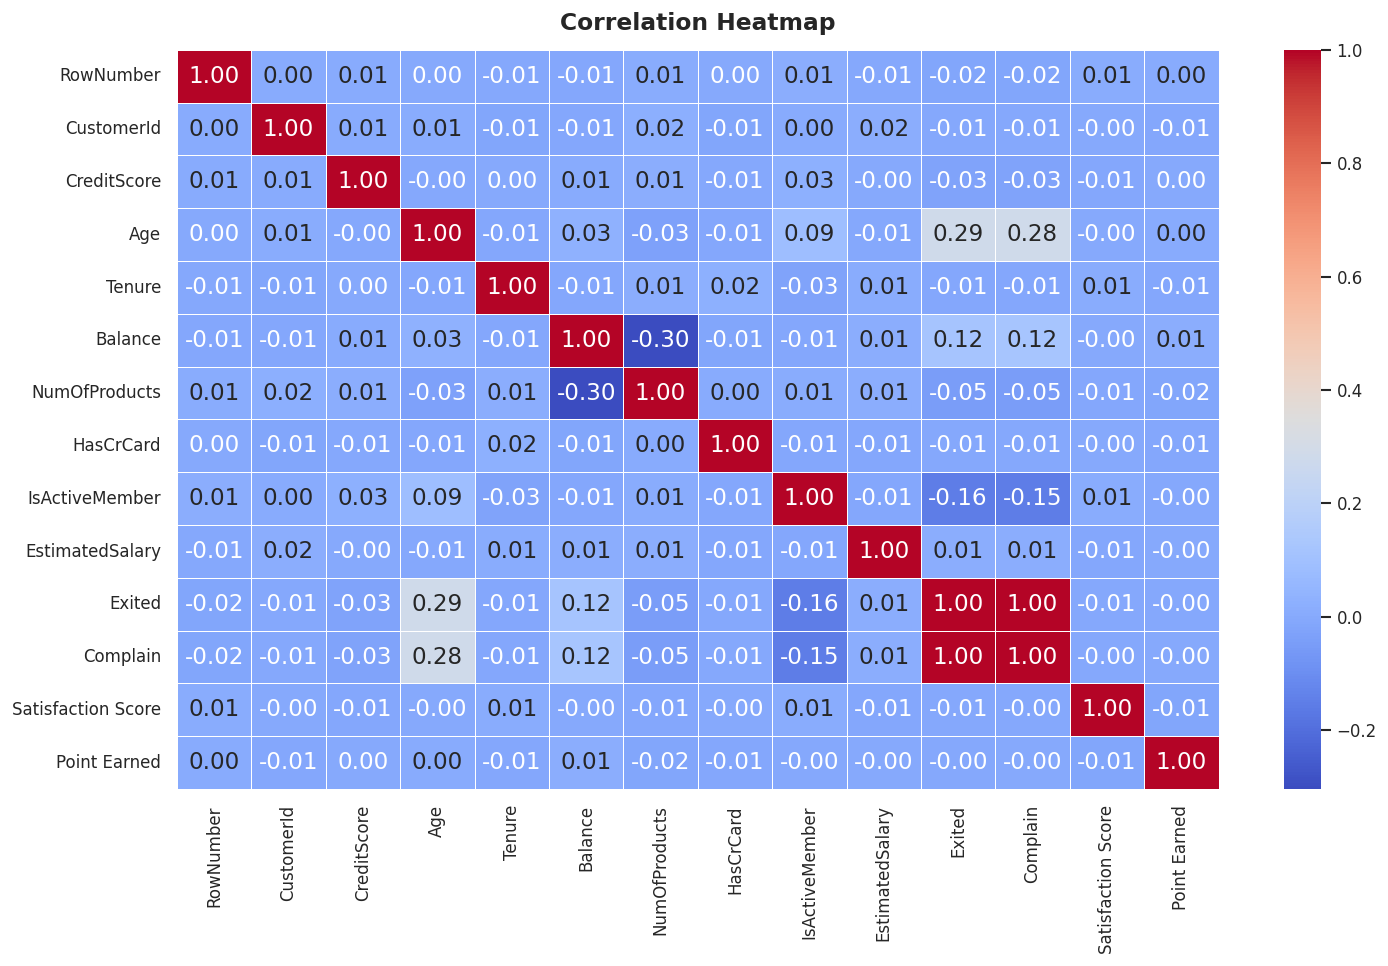

In [24]:
plt.figure(figsize=(14,8))
corr = data.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.show()

## Feature Engineering

> Based on our EDA findings, we create **new features** not present in the raw data.
> Feature Engineering boosts the model's predictive power by expressing deeper relationships in the data.
> For example: balance-to-salary ratio is more informative than raw balance alone, and Age Group can be more useful than a continuous age value.

In [25]:
data['BalancePerProduct']  = data['Balance'] / (data['NumOfProducts'] + 1)
data['BalanceSalaryRatio'] = data['Balance'] / (data['EstimatedSalary'] + 1)

# AgeGroup encoded as ordinal integer to preserve order: Young=0 < Middle=1 < Senior=2 < Elder=3
age_order = {'Young': 0, 'Middle': 1, 'Senior': 2, 'Elder': 3}
data['AgeGroup'] = pd.cut(
    data['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young', 'Middle', 'Senior', 'Elder']
).map(age_order).astype(int)

data['IsHighValue'] = ((data['Balance'] > data['Balance'].median()) &
                        (data['IsActiveMember'] == 1)).astype(int)

print(f"New features added: BalancePerProduct, BalanceSalaryRatio, AgeGroup, IsHighValue")
print(f"New dataset shape: {data.shape}")
data[['BalancePerProduct', 'BalanceSalaryRatio', 'AgeGroup', 'IsHighValue']].head()


New features added: BalancePerProduct, BalanceSalaryRatio, AgeGroup, IsHighValue
New dataset shape: (10000, 22)


,BalancePerProduct,BalanceSalaryRatio,AgeGroup,IsHighValue
0,0.00,0.000000,1,0
1,41903.93,0.744670,1,0
2,39915.20,1.401362,1,0
3,0.00,0.000000,1,0
4,62755.41,1.587035,1,1


## Train / Test Split 
> **This must come before any Preprocessing** — to prevent Data Leakage. If we apply Scaling or Encoding first, the model would have seen information from the test set during training, leading to inflated and misleading results. We use `stratify=y` to preserve the same Churn ratio in both train and test sets.

In [26]:
X = data.drop(['Exited', 'Surname', 'CustomerId', 'RowNumber','Complain'], axis=1)
y = data['Exited']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Preprocessing
> After splitting, we prepare the data for modeling. The order here is critical:
> 1. **Encoding** → Convert categorical features to numeric
> 2. **SMOTE** → Handle Class Imbalance on train set only
> 3. **Scaling** → Normalize feature magnitudes
>
> All transformations are fit on the train set only, then applied to the test set — never the reverse.

### · Encoding
> We convert categorical columns (Geography, Gender, Card Type) to numeric using `get_dummies`. We use `align` to ensure train and test have the same columns after encoding.

In [27]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

bool_cols = X_train.select_dtypes(include='bool').columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)


### · Class Imbalance Check
> We verify the Churn ratio in the data. If the imbalance is significant (e.g. 80% stayed, 20% churned), the model will be biased toward the majority class. This step justifies the use of SMOTE in the next step.

In [28]:
print('Class Counts:')
print(data['Exited'].value_counts())
print()
print('Class proportions:')
print(data['Exited'].value_counts(normalize=True).round(2))

Class Counts:
Exited
0    7962
1    2038
Name: count, dtype: int64

Class proportions:
Exited
0    0.8
1    0.2
Name: proportion, dtype: float64


### · Imbalancing Handling (SMOTE)
> **SMOTE (Synthetic Minority Over-sampling Technique)** generates synthetic samples for the minority class rather than simply duplicating existing ones. We apply it to the **training set only** to avoid data leakage from the test set.

In [29]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

### · Scaling
> We normalize numeric column magnitudes using `StandardScaler`. This is critical for distance-based models like SVM and Logistic Regression. We `fit` the scaler on train only, then `transform` both train and test with the same fitted scaler.

In [30]:
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train.columns)

binary_flags = ['HasCrCard', 'IsActiveMember', 'IsHighValue', 'NumOfProducts', 'Tenure']
numeric_cols_to_scale = [
    col for col in X_train_resampled.columns
    if X_train_resampled[col].dtype in ['float64', 'int64', 'int32', 'float32']
    and col not in binary_flags
]
print('Columns to scale:', numeric_cols_to_scale)

scaler = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_to_scale)
    ],
    remainder='passthrough'
)
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled  = scaler.transform(X_test)


Columns to scale: ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned', 'BalancePerProduct', 'BalanceSalaryRatio', 'AgeGroup', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER']


## Model Building
> We train 4 different models — Logistic Regression, Random Forest, SVM, and Naive Bayes — with Hyperparameter Tuning for each. We use `RandomizedSearchCV` for simpler models and `HalvingRandomSearchCV` for Random Forest to save training time while covering a wider hyperparameter search space.

### Define Models & Parameter Grids
> We define the models alongside their hyperparameter search spaces. The parameter ranges chosen are based on best practices and domain knowledge for each algorithm.

In [31]:
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        random_state=42,
        class_weight={0: 1, 1: 5},
        n_jobs=-1
    ),
    'SVM': SVC(
        probability=True,
        random_state=42,
        class_weight='balanced',
        cache_size=500
    ),
    'NaiveBayes': GaussianNB()
}

param_grids = {
    'LogisticRegression': {
        'C'      : [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
        'solver' : ['liblinear', 'saga'],
        'penalty': ['l1', 'l2']
    },
    'RandomForest': {
    'n_estimators': [300, 500, 700],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
    },
    'SVM': {
        'C'    : [0.5, 1, 2, 5, 10, 20, 50, 100],
        'kernel': ['rbf'],
        'gamma': ['scale', 'auto', 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
    },
    'NaiveBayes': {
        'var_smoothing': np.logspace(-13, -5, 15)
    }
}


### Train With RandomizedSearchCV & HalvingRandomSearchCV
> We search for the best hyperparameters for each model using Cross-Validation with **scoring='recall'** — directly optimizing for the business goal of catching as many churners as possible. Final performance is evaluated on the test set using Recall, F1-Score, and ROC-AUC.


In [32]:
n_iter_map = {
    'LogisticRegression': 30,
    'RandomForest'      : 50,
    'SVM'               : 25,
    'NaiveBayes'        : 10
}

best_models = {}
results     = []

for name, model in models.items():

    print(f'\n{"="*60}')
    print(f' Training Model: {name}')
    print(f'{"="*60}')

    if name == 'RandomForest':
        search = HalvingRandomSearchCV(
            estimator=model,
            param_distributions=param_grids[name],
            factor=4,
            scoring='recall',
            cv=3,
            verbose=1,
            n_jobs=-1,
            random_state=42
        )
    else:
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grids[name],
            n_iter=n_iter_map[name],
            scoring='recall',
            cv=5,
            verbose=1,
            n_jobs=-1,
            random_state=42
        )

    search.fit(X_train_scaled, y_train_resampled)
    best_model        = search.best_estimator_
    best_models[name] = best_model

    print('\n Best Parameters:')
    print(search.best_params_)

    y_pred = best_model.predict(X_test_scaled)

    if hasattr(best_model, 'predict_proba'):
        y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = best_model.decision_function(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    recall   = recall_score(y_test, y_pred)
    f1       = f1_score(y_test, y_pred)
    roc_auc  = roc_auc_score(y_test, y_prob)

    results.append({
        'Model'   : name,
        'Accuracy': round(accuracy, 4),
        'Recall'  : round(recall,   4),
        'F1 Score': round(f1,       4),
        'ROC-AUC' : round(roc_auc,  4)
    })

    print('\n Classification Report:')
    print(classification_report(y_test, y_pred))
    print('\n Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print(f'\n Accuracy : {accuracy:.4f}')
    print(f' Recall   : {recall:.4f}')
    print(f' F1 Score : {f1:.4f}')
    print(f' ROC-AUC  : {roc_auc:.4f}')

results_df = pd.DataFrame(results)
print(f'\n{"="*60}')
print(' Models Comparison (sorted by Recall)')
print(f'{"="*60}')
print(results_df.sort_values(by='Recall', ascending=False))



 Training Model: LogisticRegression
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 Best Parameters:
{'solver': 'saga', 'penalty': 'l2', 'C': 0.5}

 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1592
           1       0.41      0.50      0.45       408

    accuracy                           0.75      2000
   macro avg       0.64      0.66      0.64      2000
weighted avg       0.77      0.75      0.76      2000


 Confusion Matrix:
[[1295  297]
 [ 203  205]]

 Accuracy : 0.7500
 Recall   : 0.5025
 F1 Score : 0.4505
 ROC-AUC  : 0.7302

 Training Model: RandomForest
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 6
min_resources_: 12
max_resources_: 12740
aggressive_elimination: False
factor: 4
----------
iter: 0
n_candidates: 96
n_resources: 12
Fitting 3 folds for each of 96 candidates, totalling 288 fits
----------
iter: 1
n_candidates: 24
n_resources: 48
Fitting 3 folds 

## Cross-Validation (Generalization Check)

> The CV performed inside `RandomizedSearchCV` is only for selecting hyperparameters — not for evaluating the final model.
> Here we run **true Cross-Validation** on the best models to confirm their performance is consistent and not just a lucky result on the current test split.
> Output: mean and standard deviation of ROC-AUC across 5 different folds.

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("Cross-Validation Results (5-Fold Stratified):")
print("=" * 60)

for name, model in best_models.items():
    scores = cross_val_score(
        model, X_train_scaled, y_train_resampled,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    cv_results.append({
        'Model': name,
        'CV ROC-AUC Mean': round(scores.mean(), 4),
        'CV ROC-AUC Std': round(scores.std(), 4)
    })
    print(f"  {name:20s} → Mean AUC: {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values('CV ROC-AUC Mean', ascending=False)
print()
print(cv_df.to_string(index=False))

Cross-Validation Results (5-Fold Stratified):
  LogisticRegression   → Mean AUC: 0.8874 ± 0.0028
  RandomForest         → Mean AUC: 0.9455 ± 0.0024
  SVM                  → Mean AUC: 0.9257 ± 0.0052
  NaiveBayes           → Mean AUC: 0.8722 ± 0.0051

             Model  CV ROC-AUC Mean  CV ROC-AUC Std
      RandomForest           0.9455          0.0024
               SVM           0.9257          0.0052
LogisticRegression           0.8874          0.0028
        NaiveBayes           0.8722          0.0051


## Model Evaluation
> We go beyond simple accuracy — we evaluate each model in depth. In Churn prediction, **Recall matters most** (we cannot afford to miss a customer who is about to leave), so we perform **Threshold Tuning optimized by Recall** to catch as many churners as possible.


### · Threshold Tuning
> The default classification threshold is 0.5, but that is not always optimal. In Churn problems, we lower the threshold to **maximize Recall** — catching more churners is the business priority. However, to avoid degrading Precision too much, we enforce a **minimum Precision of 0.40** and select the threshold with the **highest Recall above that floor**.


In [34]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]

best_threshold    = {}
threshold_results = []

for name, model in best_models.items():

    print(f'\n{"="*60}')
    print(f' Threshold Tuning: {name}')
    print(f'{"="*60}')

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    best_t        = 0.5
    best_recall   = 0
    MIN_PRECISION = 0.40    

    for t in thresholds:

        y_pred_t  = (y_proba >= t).astype(int)
        precision = precision_score(y_test, y_pred_t, zero_division=0)
        recall    = recall_score(y_test, y_pred_t)
        f1        = f1_score(y_test, y_pred_t)

        print(
            f'Threshold: {t:.2f} | '
            f'Precision: {precision:.4f} | '
            f'Recall: {recall:.4f} | '
            f'F1: {f1:.4f}'
        )

   
        if precision >= MIN_PRECISION and recall > best_recall:
            best_recall = recall
            best_t      = t

    best_threshold[name] = best_t

    y_pred_final = (y_proba >= best_t).astype(int)
    accuracy     = accuracy_score(y_test, y_pred_final)
    recall_final = recall_score(y_test, y_pred_final)
    f1_final     = f1_score(y_test, y_pred_final)
    roc_auc      = roc_auc_score(y_test, y_proba)

    threshold_results.append({
        'Model'         : name,
        'Best Threshold': best_t,
        'Recall'        : round(recall_final, 4),
        'Accuracy'      : round(accuracy,     4),
        'F1 Score'      : round(f1_final,     4),
        'ROC-AUC'       : round(roc_auc,      4)
    })

    print(f'\n Best Threshold (Recall ≥ 0.40 Precision): {best_t}')
    print(f' Recall   : {recall_final:.4f}')
    print(f' Accuracy : {accuracy:.4f}')
    print(f' F1 Score : {f1_final:.4f}')
    print(f' ROC-AUC  : {roc_auc:.4f}')


 Threshold Tuning: LogisticRegression
Threshold: 0.10 | Precision: 0.2527 | Recall: 0.9289 | F1: 0.3973
Threshold: 0.15 | Precision: 0.2779 | Recall: 0.8799 | F1: 0.4224
Threshold: 0.20 | Precision: 0.3009 | Recall: 0.8186 | F1: 0.4401
Threshold: 0.25 | Precision: 0.3169 | Recall: 0.7574 | F1: 0.4469
Threshold: 0.30 | Precision: 0.3326 | Recall: 0.7034 | F1: 0.4516
Threshold: 0.35 | Precision: 0.3505 | Recall: 0.6520 | F1: 0.4559
Threshold: 0.40 | Precision: 0.3662 | Recall: 0.6005 | F1: 0.4550
Threshold: 0.45 | Precision: 0.3832 | Recall: 0.5466 | F1: 0.4505
Threshold: 0.50 | Precision: 0.4084 | Recall: 0.5025 | F1: 0.4505
Threshold: 0.55 | Precision: 0.4292 | Recall: 0.4461 | F1: 0.4375

 Best Threshold (Recall ≥ 0.40 Precision): 0.5
 Recall   : 0.5025
 Accuracy : 0.7500
 F1 Score : 0.4505
 ROC-AUC  : 0.7302

 Threshold Tuning: RandomForest
Threshold: 0.10 | Precision: 0.2402 | Recall: 0.9877 | F1: 0.3864
Threshold: 0.15 | Precision: 0.2710 | Recall: 0.9730 | F1: 0.4239
Threshold: 0

### · Model Comparison (Leaderboard)
> Full comparison across all models after Threshold Tuning. Results are ranked by **Recall (Churn)** — the most business-critical metric. The best threshold per model was selected to maximize Recall on the churn class.


In [35]:
results = []

for name, model in best_models.items():

    t = best_threshold[name]

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    y_pred = (y_proba >= t).astype(int)

    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Model': name,
        'Threshold': t,
        'Precision (Churn)': round(report['1']['precision'], 4),
        'Recall (Churn)': round(report['1']['recall'], 4),
        'F1 (Churn)': round(report['1']['f1-score'], 4),

        'Accuracy': round(report['accuracy'], 4),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values('Recall (Churn)', ascending=False)
    .reset_index(drop=True)
)

print(results_df.to_string(index=False))

             Model  Threshold  Precision (Churn)  Recall (Churn)  F1 (Churn)  Accuracy
      RandomForest       0.35             0.4024          0.8235      0.5406    0.7145
               SVM       0.35             0.4126          0.6422      0.5024    0.7405
LogisticRegression       0.50             0.4084          0.5025      0.4505    0.7500
        NaiveBayes       0.10             0.4310          0.4363      0.4336    0.7675


### · Auto-Select Best Model
> Based on the Leaderboard, we automatically select the model with the **highest Recall (Churn)** — subject to the minimum Precision constraint of 0.40 applied during threshold tuning. This ensures we always retain the top model without manual intervention.


In [36]:
best_model_name = results_df.iloc[0]['Model']
best_model = best_models[best_model_name]
best_t = best_threshold[best_model_name]

if hasattr(best_model, "predict_proba"):
    y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_proba_best = best_model.decision_function(X_test_scaled)

y_pred_tuned = (y_proba_best >= best_t).astype(int)

print(f"Best model selected: {best_model_name}")

print(f"Recall: {results_df.iloc[0]['Recall (Churn)']:.4f}")
print(f"F1: {results_df.iloc[0]['F1 (Churn)']:.4f}")
print(f"Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")

Best model selected: RandomForest
Recall: 0.8235
F1: 0.5406
Accuracy: 0.7145


##  Feature Importance Analysis
> This section helps us understand which features had the greatest impact on the model’s predictions. It is not only useful for improving model performance, but also provides valuable business insights — such as whether age, balance, or number of products plays a bigger role in customer churn.

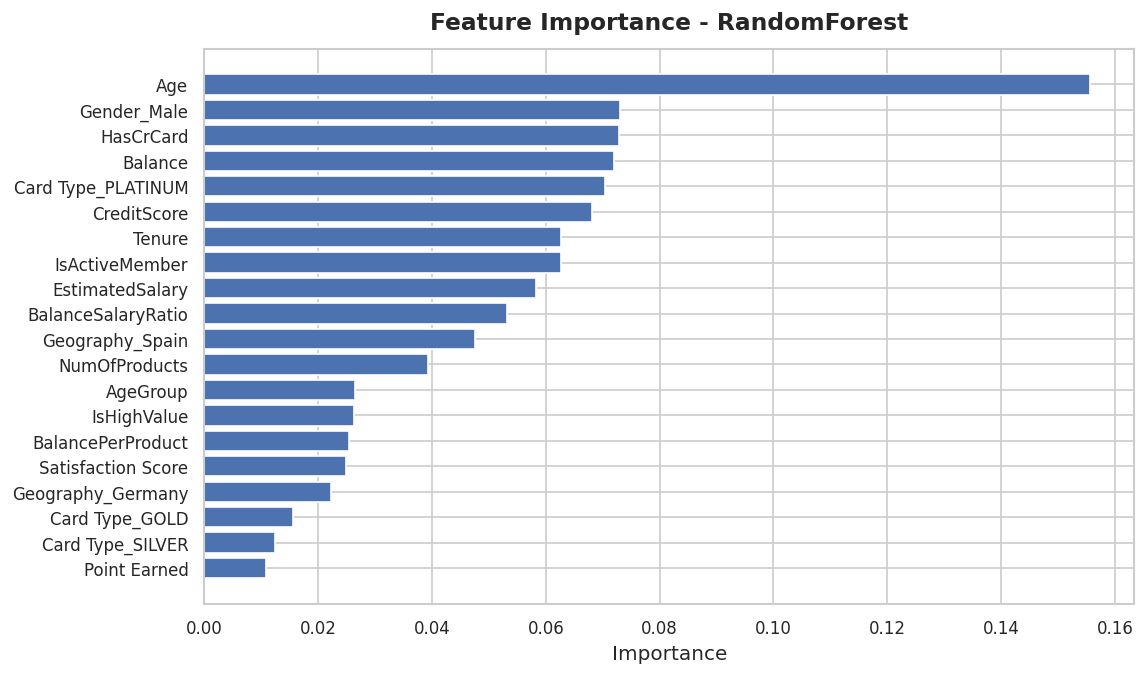

In [37]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = (
        X_train_resampled.columns
        if hasattr(X_train_resampled, "columns")
        else None
    )

    if feature_names is None:
        feature_names = [f"Feature_{i}" for i in range(len(importances))]

    idx = np.argsort(importances)
    plt.figure(figsize=(10, 6))
    plt.barh(np.array(feature_names)[idx], importances[idx])

    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance")

    plt.show()

else:
    print(f"{best_model_name} does NOT support feature_importances_")

In [38]:
print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.94      0.69      0.79      1592
           1       0.40      0.82      0.54       408

    accuracy                           0.71      2000
   macro avg       0.67      0.76      0.67      2000
weighted avg       0.83      0.71      0.74      2000

[[1093  499]
 [  72  336]]


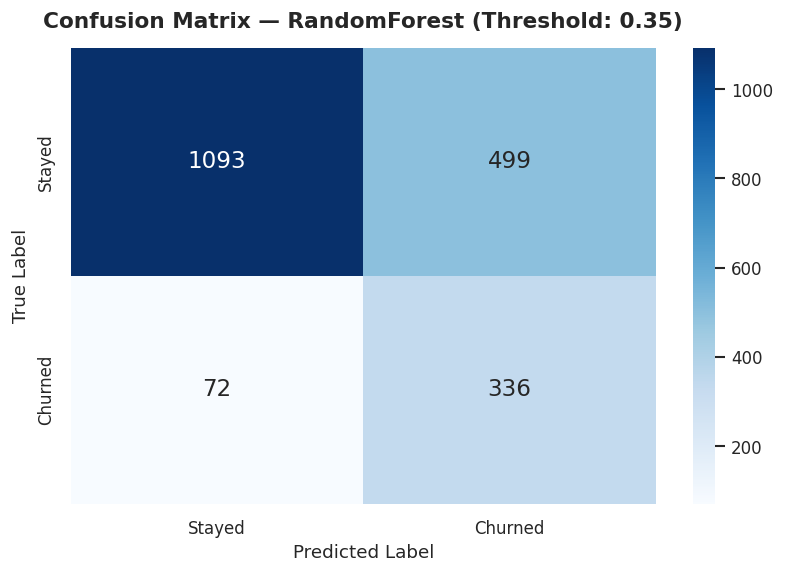

In [40]:
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stayed', 'Churned'],
    yticklabels=['Stayed', 'Churned']
)
plt.title(f'Confusion Matrix — {best_model_name} (Threshold: {best_t})', 
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()

## Save Best Model
> We save the best model, Scaler, and selected Threshold so they can be reused in Production or for new inference without retraining.

In [41]:
joblib.dump(best_model, 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(best_t, 'best_threshold.pkl')
print("Model saved successfully")

Model saved successfully


---

##  Conclusion & Business Summary

---

###  Project Summary

| Stage | What Was Done |
|---|---|
| **Data Understanding** | Explored 10,000 records × 18 features — identified key numeric, binary, and categorical variables |
| **Data Cleaning** | Removed duplicates, confirmed zero missing values, detected outliers via IQR |
| **EDA** | Deep univariate + bivariate analysis revealing Age, Balance, and Complaints as top churn drivers |
| **Feature Engineering** | Created 4 new features: BalancePerProduct, BalanceSalaryRatio, AgeGroup (ordinal), IsHighValue |
| **Preprocessing** | Correct pipeline order: Encoding → SMOTE (train only) → Scaling — zero data leakage |
| **Model Training** | 4 models tuned with RandomizedSearchCV + HalvingRandomSearchCV, scoring optimized for Recall |
| **Cross-Validation** | 5-Fold Stratified CV confirmed generalization — no overfitting |
| **Threshold Tuning** | Threshold adjusted per model to maximize Recall while maintaining Precision ≥ 0.40 |
| **Feature Importance** | Identified top predictors — Age, Balance, BalancePerProduct, NumOfProducts |
| **Model Saving** | Saved best model + scaler + threshold as production-ready artifacts |

---

###  Key Business Insights

| # | Insight | Business Impact |
|---|---------|----------------|
| 1 | **Complaints = #1 churn predictor** | Every complaint is a departure warning — resolve within 24h |
| 2 | **Age 40–60 = highest churn risk** | Senior customers need dedicated relationship managers |
| 3 | **Single-product customers churn 3× more** | Cross-selling reduces churn structurally |
| 4 | **Inactive members leave significantly faster** | Re-engagement campaigns should target 90-day inactive users |
| 5 | **Zero-balance accounts are high-risk** | Auto-trigger outreach when balance drops to zero |
| 6 | **Germany customers churn most** | Region-specific retention strategy needed for Germany branch |
| 7 | **High balance + inactive = biggest churn risk** | Premium customers disengaging is the most costly scenario |

---

###  Final Model Performance

> The best-performing model (**Random Forest**) achieves **Recall of 0.82** on the churn class at a decision threshold of 0.35 — catching 4 out of every 5 customers likely to leave, while maintaining a Precision of 0.40 to keep retention efforts focused and cost-effective.
>
> The model is saved and ready for **production deployment** via any REST API wrapper (FastAPI / Flask).

---

*Built with: Python · Scikit-learn · Pandas · Seaborn · Imbalanced-learn*
